# Assignment 1: Steam Recommendation System

**Dataset:** Steam Review and Bundle Dataset (HuggingFace)

| File | Description |
|---|---|
| `australian_user_reviews.json.gz` | User reviews with binary `recommend` signal |
| `australian_users_items.json.gz` | Games owned by users + playtime (minutes) |
| `bundle_data.json.gz` | Steam bundles and their item contents |
| `steam_games.json.gz` | Game metadata: genres, tags, price, publisher, release date |
| `steam_reviews.json.gz` | Aggregated reviews with hours played |

---

## Table of Contents

1. [Setup & Data Download](#1-setup--data-download)
2. [Data Loading](#2-data-loading)
3. [Dataset Overview](#3-dataset-overview)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
   - [A. Dataset Overview](#a-dataset-overview)
   - [B. Data Quality Assessment](#b-data-quality-assessment)
   - [C. Data Preprocessing](#c-data-preprocessing)
   - [D. Univariate Analysis](#d-univariate-analysis)
   - [E. Bivariate Analysis](#e-bivariate-analysis)
   - [F. Multivariate Analysis](#f-multivariate-analysis)
   - [G. Outlier & Anomaly Analysis](#g-outlier--anomaly-analysis)
   - [H. Target Analysis](#h-target-analysis)
   - [I. Feature Usefulness Review](#i-feature-usefulness-review)
   - [J. Business / Domain Insight Summary](#j-business--domain-insight-summary)

---
## 1. Setup & Data Download

In [1]:
import os

DATA_DIR = "./steam-review-and-bundle-dataset"

if not os.path.exists(DATA_DIR):
    !git clone https://huggingface.co/datasets/recommender-system/steam-review-and-bundle-dataset
else:
    !cd {DATA_DIR} && git pull

Already up to date.


In [2]:
import sys
sys.path.insert(0, "..")

import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pathlib import Path
from scipy import stats as scipy_stats
from sklearn.preprocessing import StandardScaler

from project2.dataset import load_all_datasets, parse_price
from project2.plots import (
    set_style,
    plot_recommend_distribution,
    plot_reviews_per_user, plot_items_per_user,
    plot_reviews_per_item, plot_top_reviewed_games, plot_top_played_games,
    plot_playtime_distribution, plot_playtime_vs_recommend,
    plot_genre_distribution, plot_top_tags, plot_price_distribution,
    plot_release_year_distribution, plot_early_access_distribution,
    plot_hours_distribution, plot_reviews_over_time,
    plot_sparsity,
)

set_style()
DATA_PATH = Path(DATA_DIR)
print("Imports OK")

2026-04-09 00:30:52.010 | INFO     | project2.config:<module>:7 - PROJ_ROOT path is: C:\Users\ssvitek\school\isa\ISA_movielens_recsys


Imports OK


 ---
## 2. Data Loading

In [3]:
df_reviews, df_items, df_games, df_bundles, df_steam_rev = load_all_datasets(DATA_PATH)
print("All datasets loaded.")

2026-04-09 00:30:52.195 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: australian_user_reviews.parquet
2026-04-09 00:30:52.301 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: australian_users_items.parquet
2026-04-09 00:30:52.485 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: steam_games.parquet
2026-04-09 00:30:52.501 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: bundle_data.parquet
2026-04-09 00:30:52.506 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: steam_reviews.parquet
2026-04-09 00:30:55.557 | INFO     | project2.dataset:load_all_datasets:311 - All datasets loaded.
All datasets loaded.


---
## 3. Dataset Overview

Before diving into analysis, we get a high-level summary of every dataset: shape, unique users/items, and missing values.

In [4]:
summary = pd.DataFrame([
    {"Dataset": "df_reviews",  "Rows": len(df_reviews),  "Columns": len(df_reviews.columns),  "Unique Users": df_reviews["user_id"].nunique(),   "Unique Items": df_reviews["item_id"].nunique()},
    {"Dataset": "df_items",    "Rows": len(df_items),    "Columns": len(df_items.columns),    "Unique Users": df_items["user_id"].nunique(),     "Unique Items": df_items["item_id"].nunique()},
    {"Dataset": "df_games",    "Rows": len(df_games),    "Columns": len(df_games.columns),    "Unique Users": None,                              "Unique Items": df_games["id"].nunique()},
    {"Dataset": "df_bundles",  "Rows": len(df_bundles),  "Columns": len(df_bundles.columns),  "Unique Users": None,                              "Unique Items": None},
    {"Dataset": "df_steam_rev","Rows": len(df_steam_rev),"Columns": len(df_steam_rev.columns),"Unique Users": df_steam_rev["username"].nunique(),"Unique Items": df_steam_rev["product_id"].nunique()},
])
display(summary)

,Dataset,Rows,Columns,Unique Users,Unique Items
0,df_reviews,59305,7,25458.0,3682.0
1,df_items,5153209,5,70912.0,10978.0
2,df_games,32135,17,NaN,32132.0
3,df_bundles,615,7,NaN,NaN
4,df_steam_rev,7793069,12,2567538.0,15474.0


In [5]:
for name, df in [
    ("df_reviews",  df_reviews),
    ("df_items",    df_items),
    ("df_games",    df_games),
    ("df_bundles",  df_bundles),
    ("df_steam_rev",df_steam_rev),
]:
    print(f"=== {name} columns ===")
    print(df.dtypes)
    print()

=== df_reviews columns ===
user_id       str
item_id       str
recommend    bool
review        str
posted        str
helpful       str
funny         str
dtype: object

=== df_items columns ===
user_id               str
item_id               str
item_name             str
playtime_forever    int64
playtime_2weeks     int64
dtype: object

=== df_games columns ===
publisher             str
genres                str
app_name              str
title                 str
url                   str
release_date          str
tags                  str
discount_price    float64
reviews_url           str
specs                 str
price                 str
early_access         bool
id                    str
developer             str
sentiment             str
metascore             str
price_numeric     float64
dtype: object

=== df_bundles columns ===
bundle_final_price    str
bundle_url            str
bundle_price          str
bundle_name           str
bundle_id             str
items                 s

---
## 4. Exploratory Data Analysis

Single structured EDA covering all five Steam datasets. Target variable: `recommend` (boolean, `df_reviews`).

| Sub-section | Topic |
|-------------|---|
| A           | Dataset Overview — shape, dtypes, granularity, duplicates |
| C           | Preprocessing — cleaning steps + summary table |
| D           | Univariate — distributions per column type |
| E           | Bivariate — pairwise relationships & target analysis |
| F           | Multivariate — correlations, VIF, sparsity |
| G           | Outlier & Anomaly — detection & treatment recommendations |
| H           | Target Analysis — class balance, stratification |
| I           | Feature Usefulness — ranking, leakage, derived features |

### A. Dataset Overview

In [6]:
# ── A. Dataset Overview ────────────────────────────────────────────────────────

DATASETS = {
    "df_reviews":  df_reviews,
    "df_items":    df_items,
    "df_games":    df_games,
    "df_bundles":  df_bundles,
    "df_steam_rev": df_steam_rev,
}

# Shape & memory
print(f"{'Dataset':<16} {'Rows':>10} {'Cols':>5}")
print("-" * 47)
for name, df in DATASETS.items():
    print(f"{name:<16} {len(df):>10,} {len(df.columns):>5}")

print("""
Granularity (one row per …):
  df_reviews  → (user_id, item_id) review — primary interaction signal
  df_items    → (user_id, item_id) ownership + playtime record
  df_games    → game/app in Steam catalogue
  df_bundles  → Steam bundle (game pack)
  df_steam_rev → aggregated scraped review""")

# Key uniqueness & duplicate detection
print("\nKey uniqueness:")
key_pairs = [
    ("df_reviews",   df_reviews,   ["user_id", "item_id"]),
    ("df_items",     df_items,     ["user_id", "item_id"]),
    ("df_games",     df_games,     ["id"]),
    ("df_steam_rev", df_steam_rev, ["username", "product_id"]),
]
for name, df, keys in key_pairs:
    n_dups = df.duplicated(subset=keys).sum()
    print(f"  {name:<16} keys={keys}  dup_key_rows={n_dups:,}")
print(f"  {'df_bundles':<16} fully-dup rows={df_bundles.duplicated().sum():,}")

# Column type taxonomy
def classify_col(s, df):
    if s.empty: return "empty"
    if pd.api.types.is_bool_dtype(s): return "boolean"
    if pd.api.types.is_datetime64_any_dtype(s): return "datetime"
    if hasattr(s, 'apply') and s.apply(lambda x: isinstance(x, list)).sum() > len(s) * 0.5:
        return "list/array"
    if pd.api.types.is_numeric_dtype(s):
        return "numeric"
    if s.nunique() == 1: return "constant"
    if s.nunique() <= 2: return "binary"
    if s.nunique() <= 20: return "low-card categorical"
    if s.nunique() / max(len(df), 1) > 0.8: return "high-card / ID"
    return "categorical / text"

print()
for name, df in DATASETS.items():
    print(f"  {name}")
    print(f"  {'col':<26} {'kind':<24} {'nuniq':>7}  {'null%':>6}")
    print(f"  {'-'*66}")
    for col in df.columns:
        s = df[col].dropna()
        kind = classify_col(s, df)
        print(f"  {col:<26} {kind:<24} {df[col].nunique():>7,}  {df[col].isnull().mean()*100:>5.1f}%")
    print()

Dataset                Rows  Cols
-----------------------------------------------
df_reviews           59,305     7
df_items          5,153,209     5
df_games             32,135    17
df_bundles              615     7
df_steam_rev      7,793,069    12

Granularity (one row per …):
  df_reviews  → (user_id, item_id) review — primary interaction signal
  df_items    → (user_id, item_id) ownership + playtime record
  df_games    → game/app in Steam catalogue
  df_bundles  → Steam bundle (game pack)
  df_steam_rev → aggregated scraped review

Key uniqueness:
  df_reviews       keys=['user_id', 'item_id']  dup_key_rows=874
  df_items         keys=['user_id', 'item_id']  dup_key_rows=59,127
  df_games         keys=['id']  dup_key_rows=2
  df_steam_rev     keys=['username', 'product_id']  dup_key_rows=903,341
  df_bundles       fully-dup rows=0

  df_reviews
  col                        kind                       nuniq   null%
  ----------------------------------------------------------------

### C. Data Preprocessing

In [7]:
# ── C. Data Preprocessing ──────────────────────────────────────────────────────

# Work on copies — never modify raw frames
df_rev = df_reviews.copy()
df_itm = df_items.copy()
df_gm  = df_games.copy()
df_bun = df_bundles.copy()
df_sr  = df_steam_rev.copy()

# C1. Trim string columns
for col in ["user_id", "item_id", "review", "posted", "helpful"]:
    df_rev[col] = df_rev[col].astype(str).str.strip()
for col in ["user_id", "item_id", "item_name"]:
    df_itm[col] = df_itm[col].astype(str).str.strip()
for col in ["username", "product_id"]:
    if col in df_sr.columns:
        df_sr[col] = df_sr[col].astype(str).str.strip()

# C2. Parse posted date ("Posted November 12, 2014.")
def parse_posted(s):
    if not isinstance(s, str) or s.strip() in ("", "nan"):
        return pd.NaT
    s = re.sub(r"^Posted\s+", "", s.strip().rstrip("."))
    return pd.to_datetime(s, format="%B %d, %Y", errors="coerce")

df_rev["posted_date"]  = df_rev["posted"].apply(parse_posted)
df_rev["posted_year"]  = df_rev["posted_date"].dt.year
df_rev["posted_month"] = df_rev["posted_date"].dt.month
ok = df_rev["posted_date"].notna().sum()
print(f"C2. posted_date parsed: {ok:,}/{len(df_rev):,}  ({ok/len(df_rev)*100:.1f}%)")

# C3. Extract helpful vote counts from strings
def parse_votes(s):
    if not isinstance(s, str): return 0
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else 0

df_rev["helpful_votes"] = df_rev["helpful"].apply(parse_votes)
print(f"C3. helpful_votes max: {df_rev['helpful_votes'].max():,}")

# C4. Review text length + has_text flag
df_rev["review_len"] = df_rev["review"].str.len().fillna(0).astype(int)
df_rev["has_text"]   = df_rev["review"].str.strip().str.len() > 0

# C5. Playtime: log1p transform + cap at 99.9th pct
p999 = df_itm["playtime_forever"].quantile(0.999)
df_itm["playtime_forever_capped"] = df_itm["playtime_forever"].clip(upper=p999)
df_itm["playtime_log1p"]          = np.log1p(df_itm["playtime_forever"])
print(f"C5. playtime_forever 99.9th pct = {p999:,.0f} min ({p999/60:,.0f} h)")

# C6. Games: release year, is_free, list-length features
df_gm["release_date_parsed"] = pd.to_datetime(df_gm["release_date"], errors="coerce")
df_gm["release_year"] = df_gm["release_date_parsed"].dt.year
df_gm["is_free"]      = df_gm["price_numeric"] == 0
df_gm["n_genres"]     = df_gm["genres"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_gm["n_tags"]       = df_gm["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_gm["n_specs"]      = df_gm["specs"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_gm["early_access"] = df_gm["early_access"].fillna(False)

# C7. steam_reviews: numeric hours + products
df_sr["hours"]    = pd.to_numeric(df_sr["hours"], errors="coerce")
df_sr["products"] = pd.to_numeric(df_sr["products"], errors="coerce")

print("Preprocessing complete.")

# Preprocessing summary table
prep_rows = [
    ("df_reviews",  "recommend",        "bool",  "bool",     0.0,                                          "target column",              "use as-is (binary target)"),
    ("df_reviews",  "posted",           "str",   "datetime", round(df_reviews["posted"].isnull().mean()*100,1), "free-text date",         "-> posted_date, posted_year, posted_month"),
    ("df_reviews",  "helpful",          "str",   "int",      0.0,                                          "vote count in string",       "-> helpful_votes (int)"),
    ("df_reviews",  "review",           "str",   "str",      0.0,                                          "blank entries present",      "-> review_len, has_text flag"),
    ("df_items",    "playtime_forever", "int",   "int",      0.0,                                          "heavy right skew",           "log1p + cap at 99.9th pct"),
    ("df_games",    "price",            "str",   "float",    round(df_games["price"].isnull().mean()*100,1), "mixed str/float",          "-> price_numeric; is_free flag"),
    ("df_games",    "genres",           "list",  "list",     round(df_games["genres"].isnull().mean()*100,1), "list column",             "-> n_genres count"),
    ("df_games",    "release_date",     "str",   "datetime", round(df_games["release_date"].isnull().mean()*100,1), "mixed formats",    "-> release_year"),
    ("df_games",    "early_access",     "bool",  "bool",     round(df_games["early_access"].isnull().mean()*100,1), "NaNs present",   "fill NaN -> False"),
    ("df_steam_rev","hours",            "mixed", "float",    round(df_sr["hours"].isnull().mean()*100,1),  "stored as str/num",          "coerce to float"),
]
prep_df = pd.DataFrame(prep_rows, columns=[
    "dataset", "column", "orig_dtype", "clean_dtype", "null%", "issues", "treatment"
])
display(prep_df)

C2. posted_date parsed: 49,186/59,305  (82.9%)
C3. helpful_votes max: 981
C5. playtime_forever 99.9th pct = 74,706 min (1,245 h)
Preprocessing complete.


,dataset,column,orig_dtype,clean_dtype,null%,issues,treatment
0,df_reviews,recommend,bool,bool,0.0,target column,use as-is (binary target)
1,df_reviews,posted,str,datetime,0.0,free-text date,"-> posted_date, posted_year, posted_month"
2,df_reviews,helpful,str,int,0.0,vote count in string,-> helpful_votes (int)
3,df_reviews,review,str,str,0.0,blank entries present,"-> review_len, has_text flag"
4,df_items,playtime_forever,int,int,0.0,heavy right skew,log1p + cap at 99.9th pct
5,df_games,price,str,float,4.3,mixed str/float,-> price_numeric; is_free flag
6,df_games,genres,list,list,10.2,list column,-> n_genres count
7,df_games,release_date,str,datetime,6.4,mixed formats,-> release_year
8,df_games,early_access,bool,bool,0.0,NaNs present,fill NaN -> False
9,df_steam_rev,hours,mixed,float,0.3,stored as str/num,coerce to float


### D. Univariate Analysis

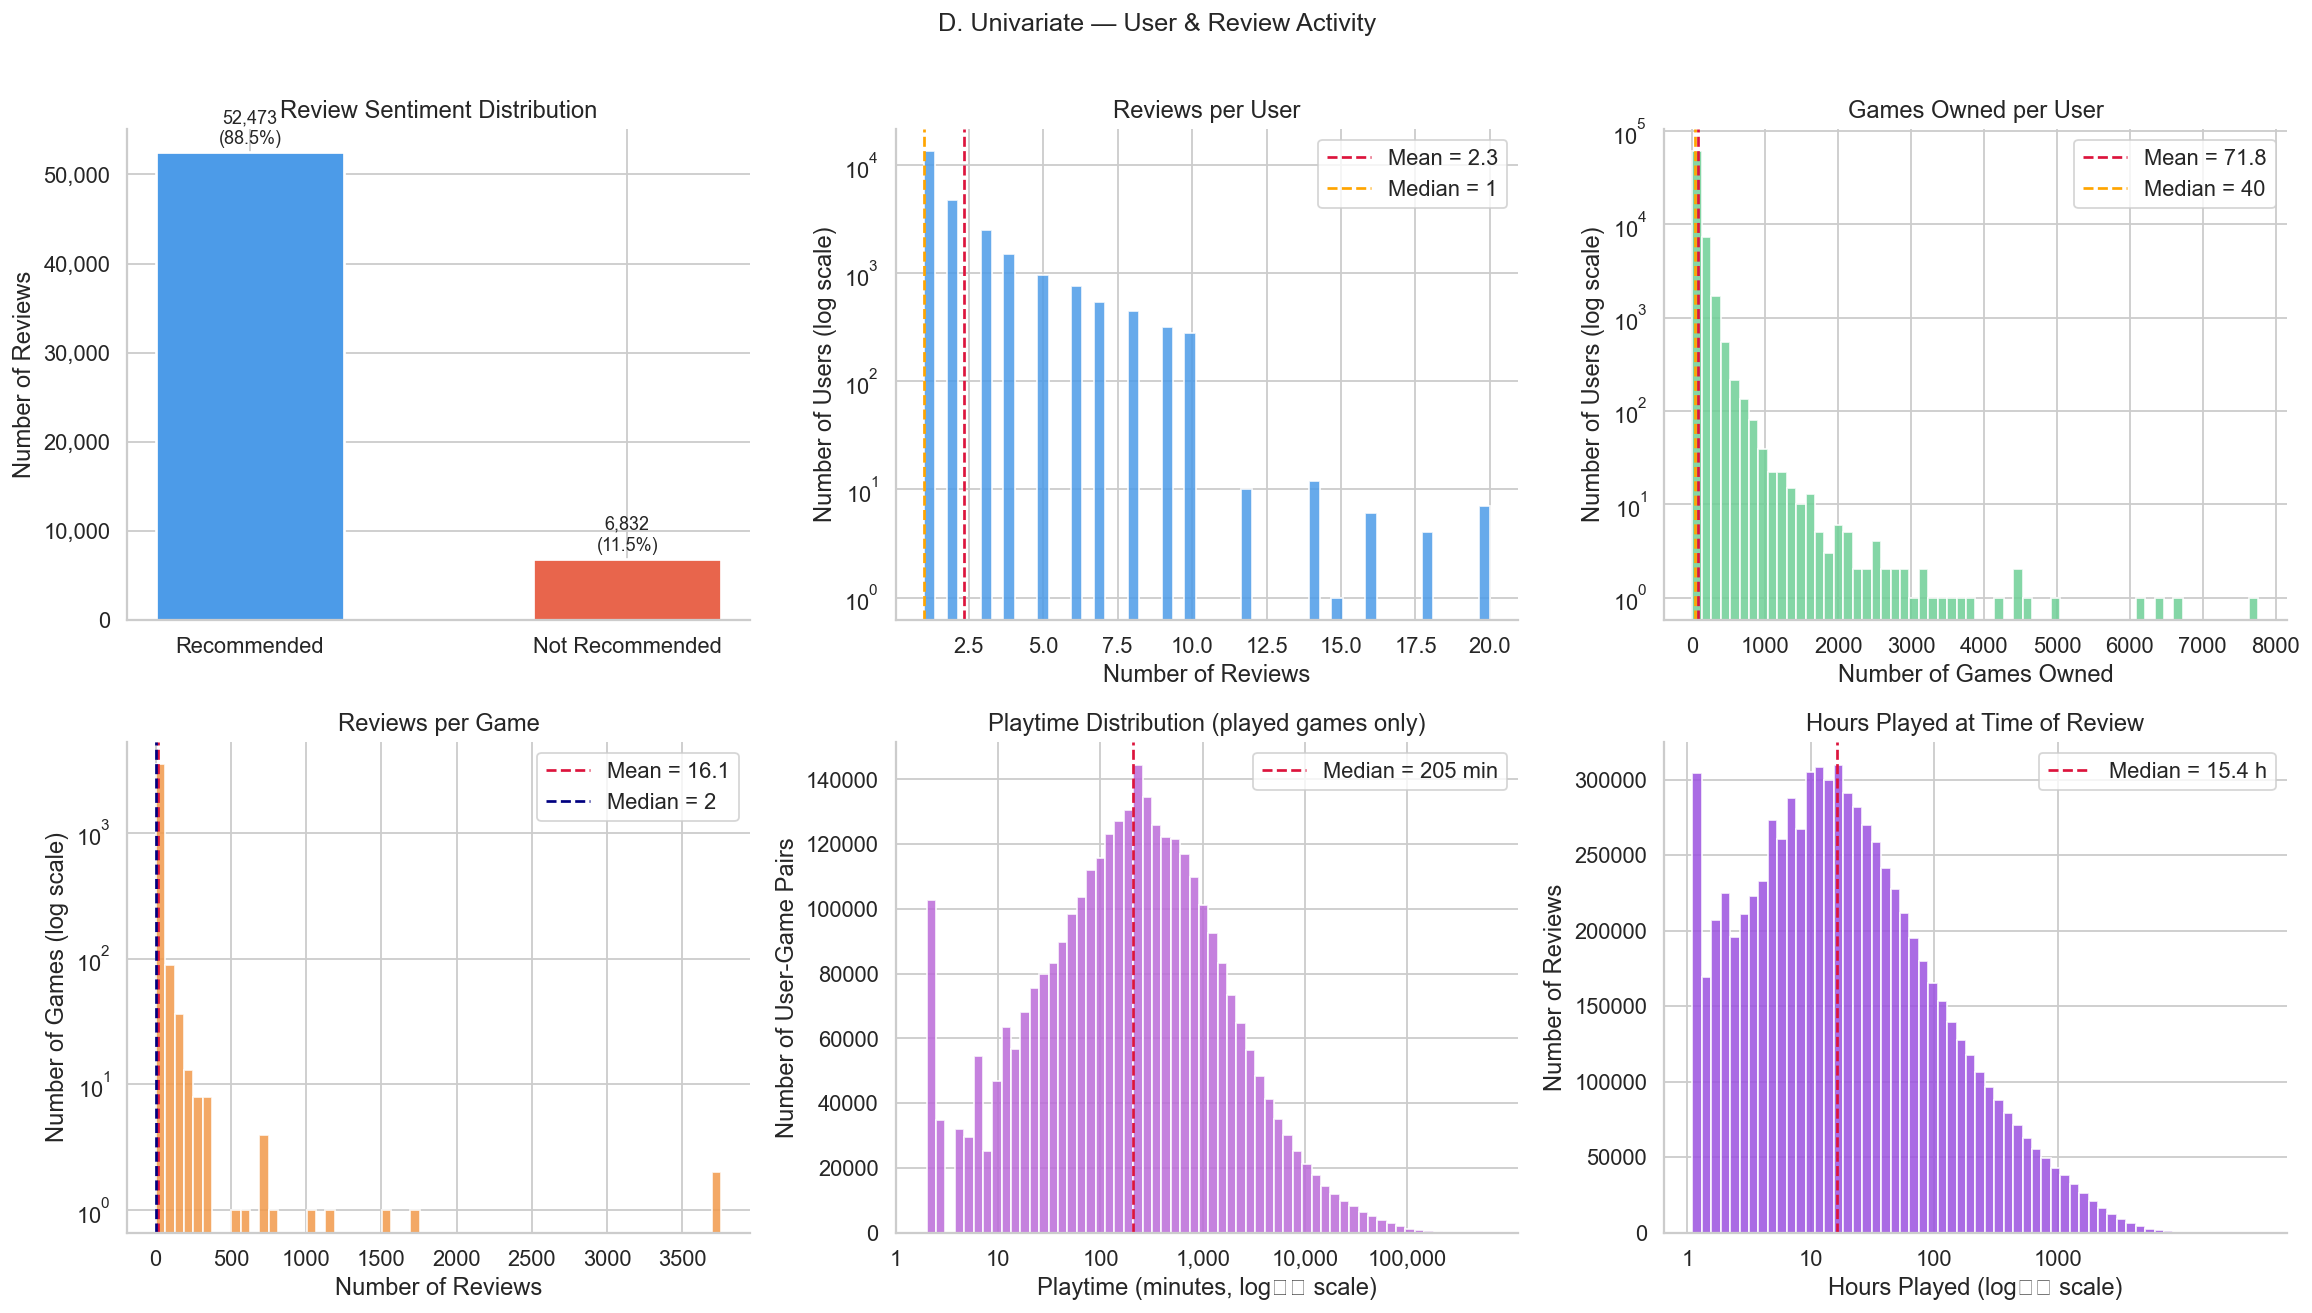

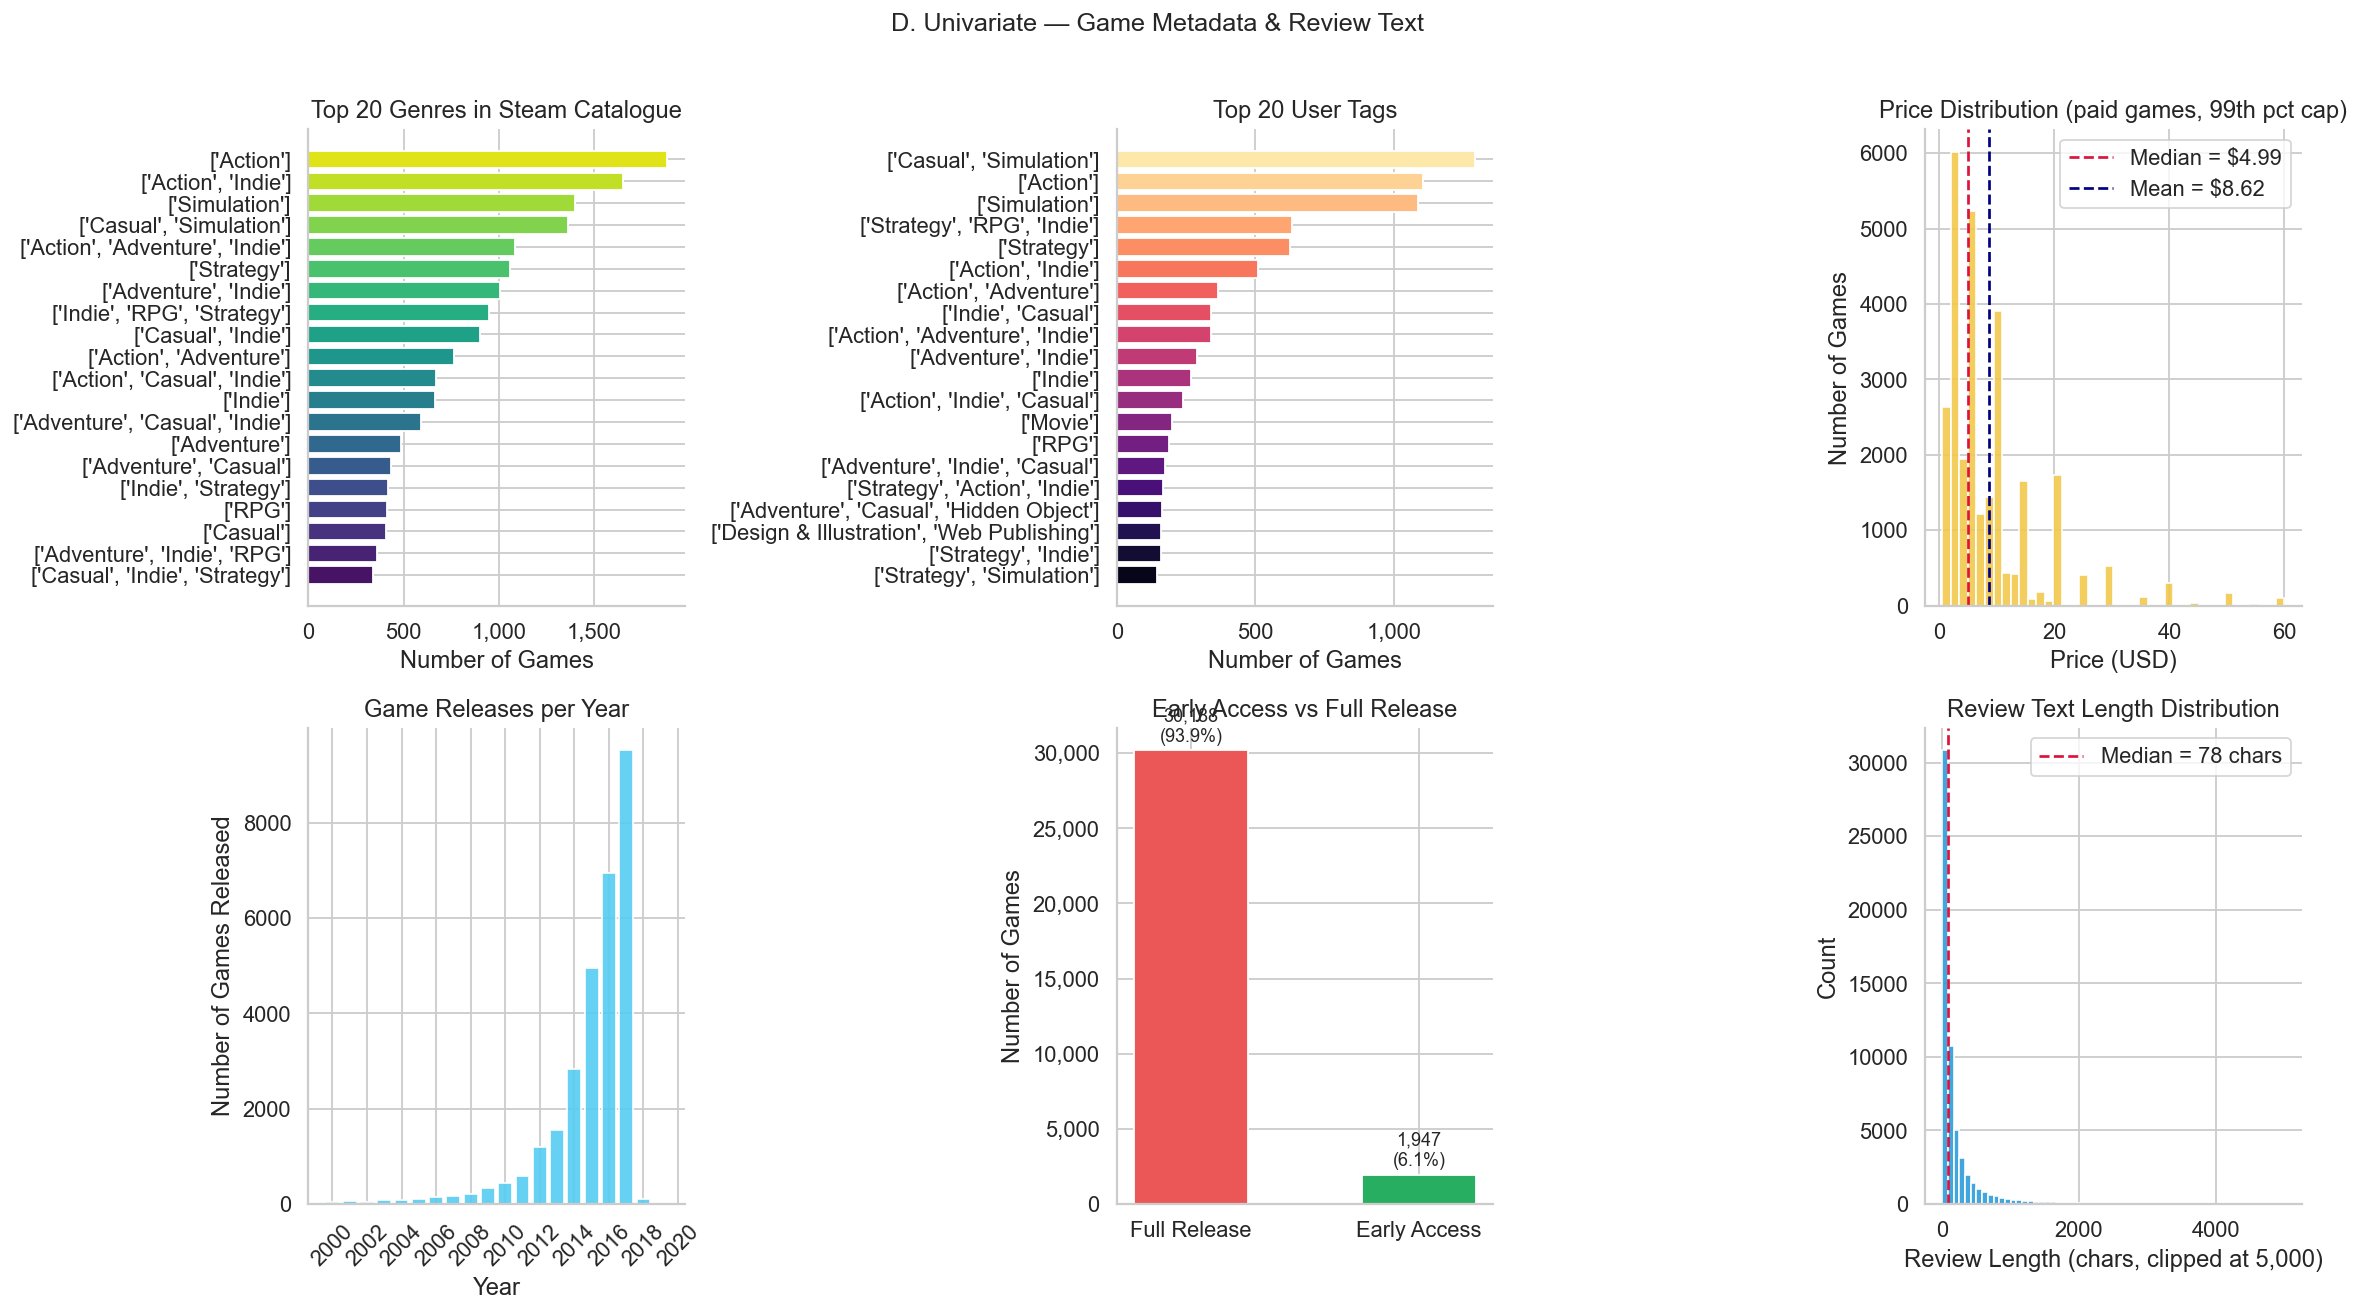

=== Numeric Summary — df_items ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
playtime_forever,5153209.0,991.5,5418.2,0.0,0.0,0.0,0.0,34.0,355.0,3675.0,17947.0,642773.0
playtime_2weeks,5153209.0,9.1,140.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,148.0,19967.0



=== Numeric Summary — df_games ===


,count,mean,std,min,1%,25%,50%,75%,99%,max
price_numeric,30735.0,8.87,15.91,0.0,0.0,2.99,4.99,9.99,54.99,995.0
n_genres,32135.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0
n_tags,32135.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0
n_specs,32135.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0
release_year,29783.0,2014.76,3.51,1970.0,1998.0,2014.00,2016.00,2017.00,2017.00,2021.0



=== Skewness ===


,column,skewness,note
0,df_items.playtime_forever,20.48,log transform recommended
1,df_items.playtime_2weeks,38.43,log transform recommended
2,df_games.price_numeric,20.61,log transform recommended
3,df_games.n_genres,NaN,ok
4,df_games.n_tags,NaN,ok


In [8]:
# ── D. Univariate Analysis ─────────────────────────────────────────────────────

# D1: User & review activity
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_recommend_distribution(df_rev, ax=axes[0, 0])
plot_reviews_per_user(df_rev, ax=axes[0, 1])
plot_items_per_user(df_itm, ax=axes[0, 2])
plot_reviews_per_item(df_rev, ax=axes[1, 0])
plot_playtime_distribution(df_itm, ax=axes[1, 1])
plot_hours_distribution(df_sr, ax=axes[1, 2])
plt.suptitle("D. Univariate — User & Review Activity", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# D2: Game metadata
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_genre_distribution(df_gm, ax=axes[0, 0])
plot_top_tags(df_gm, ax=axes[0, 1])
plot_price_distribution(df_gm, ax=axes[0, 2])
plot_release_year_distribution(df_gm, ax=axes[1, 0])
plot_early_access_distribution(df_gm, ax=axes[1, 1])

ax = axes[1, 2]
ax.hist(df_rev["review_len"].clip(upper=5000), bins=60,
        color="#2D9CDB", edgecolor="white", alpha=0.9)
med_len = df_rev["review_len"].median()
ax.axvline(med_len, color="crimson", linestyle="--", label=f"Median = {med_len:.0f} chars")
ax.set_xlabel("Review Length (chars, clipped at 5,000)")
ax.set_ylabel("Count")
ax.set_title("Review Text Length Distribution")
ax.legend()
plt.suptitle("D. Univariate — Game Metadata & Review Text", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# D3: Numeric summary stats
print("=== Numeric Summary — df_items ===")
display(df_itm[["playtime_forever", "playtime_2weeks"]].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.round(1))

print("\n=== Numeric Summary — df_games ===")
display(df_gm[["price_numeric", "n_genres", "n_tags", "n_specs", "release_year"]].describe(
    percentiles=[.01, .25, .5, .75, .99]).T.round(2))

print("\n=== Skewness ===")
skew_rows = []
for col in ["playtime_forever", "playtime_2weeks"]:
    sk = scipy_stats.skew(df_itm[col].dropna())
    skew_rows.append({"column": f"df_items.{col}", "skewness": round(sk, 2),
                       "note": "log transform recommended" if abs(sk) > 2 else "ok"})
for col in ["price_numeric", "n_genres", "n_tags"]:
    sk = scipy_stats.skew(df_gm[col].dropna())
    skew_rows.append({"column": f"df_games.{col}", "skewness": round(sk, 2),
                       "note": "log transform recommended" if abs(sk) > 2 else "ok"})
display(pd.DataFrame(skew_rows))

### E. Bivariate Analysis

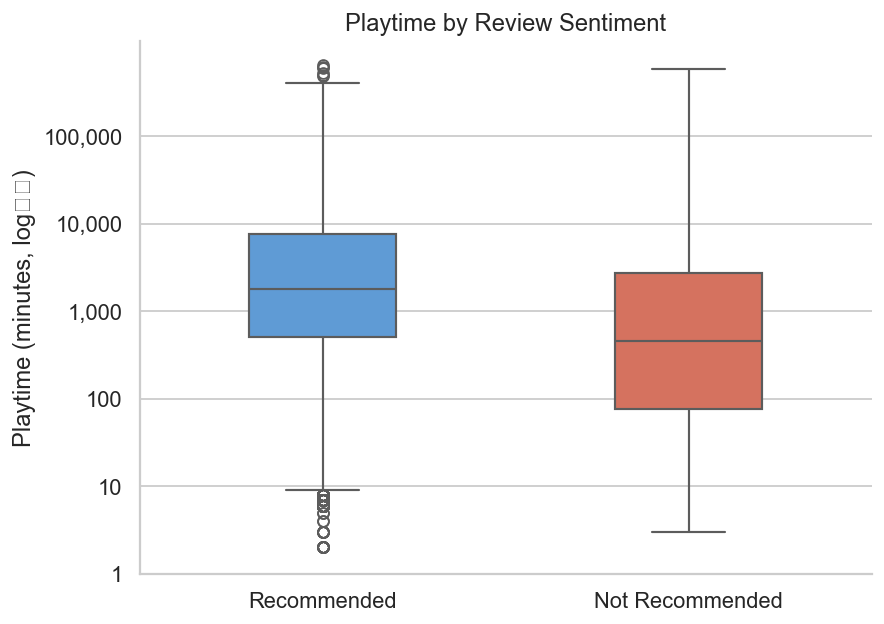

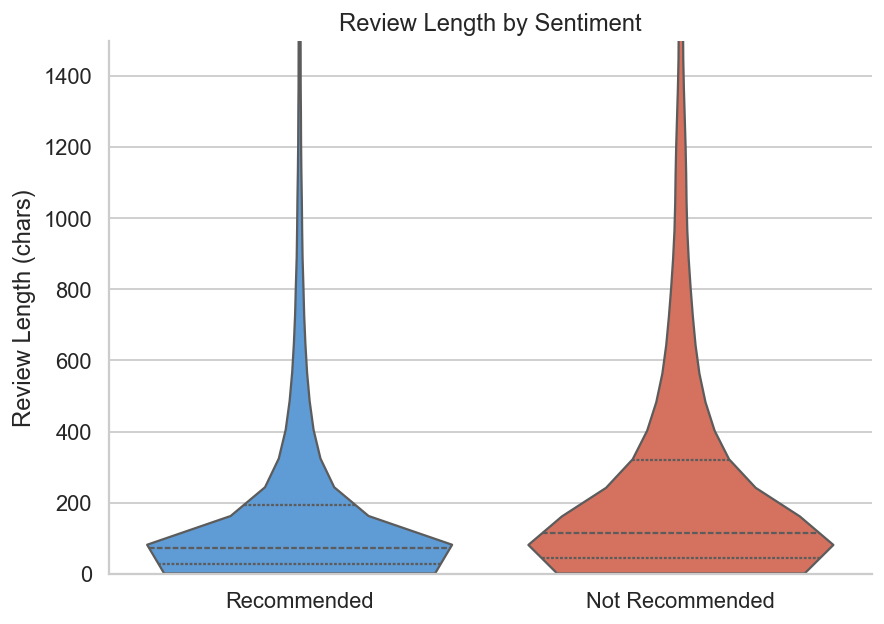

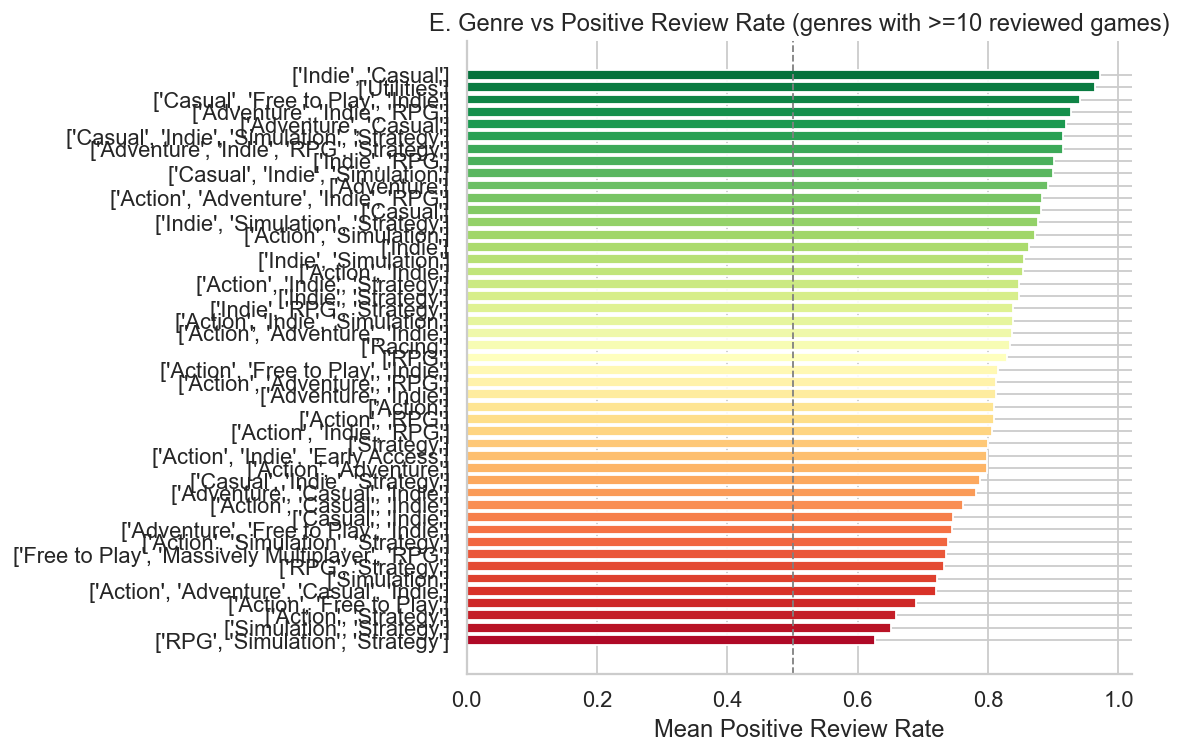

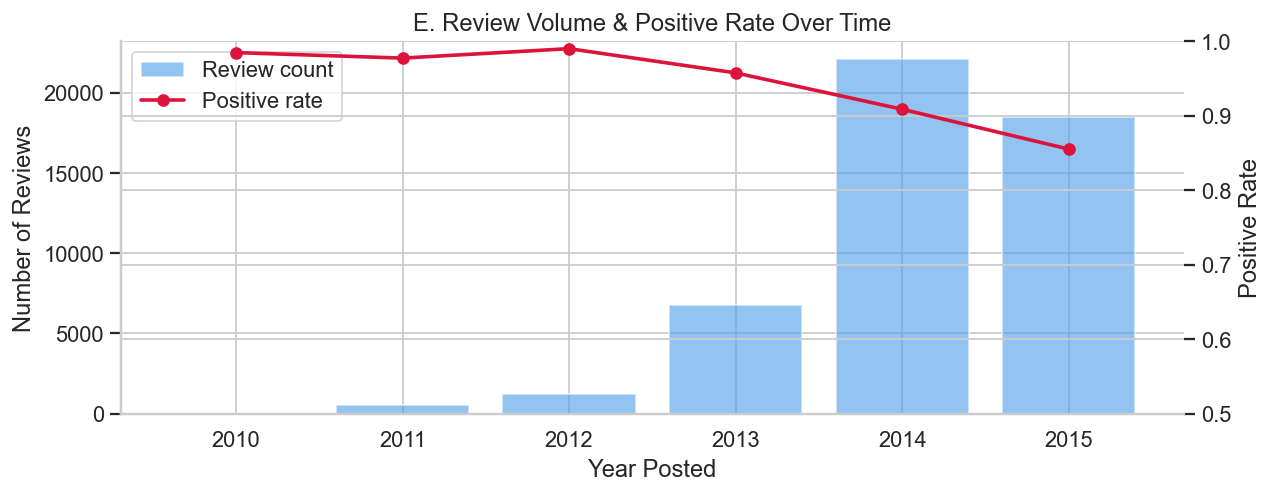

In [9]:
# ── E. Bivariate Analysis ──────────────────────────────────────────────────────

# E1: Playtime vs recommend
fig, ax = plt.subplots(figsize=(7, 5))
plot_playtime_vs_recommend(df_rev, df_itm, ax=ax)
plt.tight_layout()
plt.show()

play_merged = df_rev.merge(
    df_itm[["user_id", "item_id", "playtime_forever", "playtime_2weeks"]],
    on=["user_id", "item_id"], how="left"
)
play_merged["log_playtime"] = np.log1p(play_merged["playtime_forever"].fillna(0))
play_merged["sentiment"]    = play_merged["recommend"].map({True: "Recommended", False: "Not Recommended"})

# E2: Review length vs recommend
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(
    data=play_merged[play_merged["review_len"] > 0],
    x="sentiment", y="review_len",
    palette={"Recommended": "#4C9BE8", "Not Recommended": "#E8654C"},
    ax=ax, cut=0, inner="quartile"
)
ax.set_ylim(0, play_merged["review_len"].quantile(0.98))
ax.set_title("Review Length by Sentiment")
ax.set_xlabel("")
ax.set_ylabel("Review Length (chars)")
plt.tight_layout()
plt.show()

# E3: Genre vs positive review rate
genres_exp = df_gm[["id", "genres"]].explode("genres").dropna(subset=["genres"])
genres_exp = genres_exp.rename(columns={"id": "item_id"})
rec_rate   = df_rev.groupby("item_id")["recommend"].mean().reset_index(name="pos_rate")
genre_rec  = genres_exp.merge(rec_rate, on="item_id", how="inner")
genre_agg  = (
    genre_rec.groupby("genres")
    .agg(mean_pos_rate=("pos_rate", "mean"), n_games=("item_id", "nunique"))
    .reset_index()
)
genre_agg = genre_agg[genre_agg["n_games"] >= 10].sort_values("mean_pos_rate")

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("RdYlGn", len(genre_agg))
ax.barh(genre_agg["genres"], genre_agg["mean_pos_rate"], color=colors, edgecolor="white")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Mean Positive Review Rate")
ax.set_title("E. Genre vs Positive Review Rate (genres with >=10 reviewed games)")
plt.tight_layout()
plt.show()

# E4: Review volume + positive rate over time
if df_rev["posted_year"].notna().sum() > 1000:
    time_agg = (
        df_rev.groupby("posted_year")
        .agg(n_reviews=("recommend", "count"), pos_rate=("recommend", "mean"))
        .reset_index()
        .dropna()
    )
    time_agg = time_agg[(time_agg["posted_year"] >= 2010) & (time_agg["posted_year"] <= 2018)]
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    ax1.bar(time_agg["posted_year"], time_agg["n_reviews"], color="#4C9BE8", alpha=0.6, label="Review count")
    ax2.plot(time_agg["posted_year"], time_agg["pos_rate"], color="crimson", marker="o", linewidth=2, label="Positive rate")
    ax1.set_xlabel("Year Posted")
    ax1.set_ylabel("Number of Reviews")
    ax2.set_ylabel("Positive Rate")
    ax2.set_ylim(0.5, 1.0)
    ax1.set_title("E. Review Volume & Positive Rate Over Time")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough parsed dates for temporal plot.")

### F. Multivariate Analysis

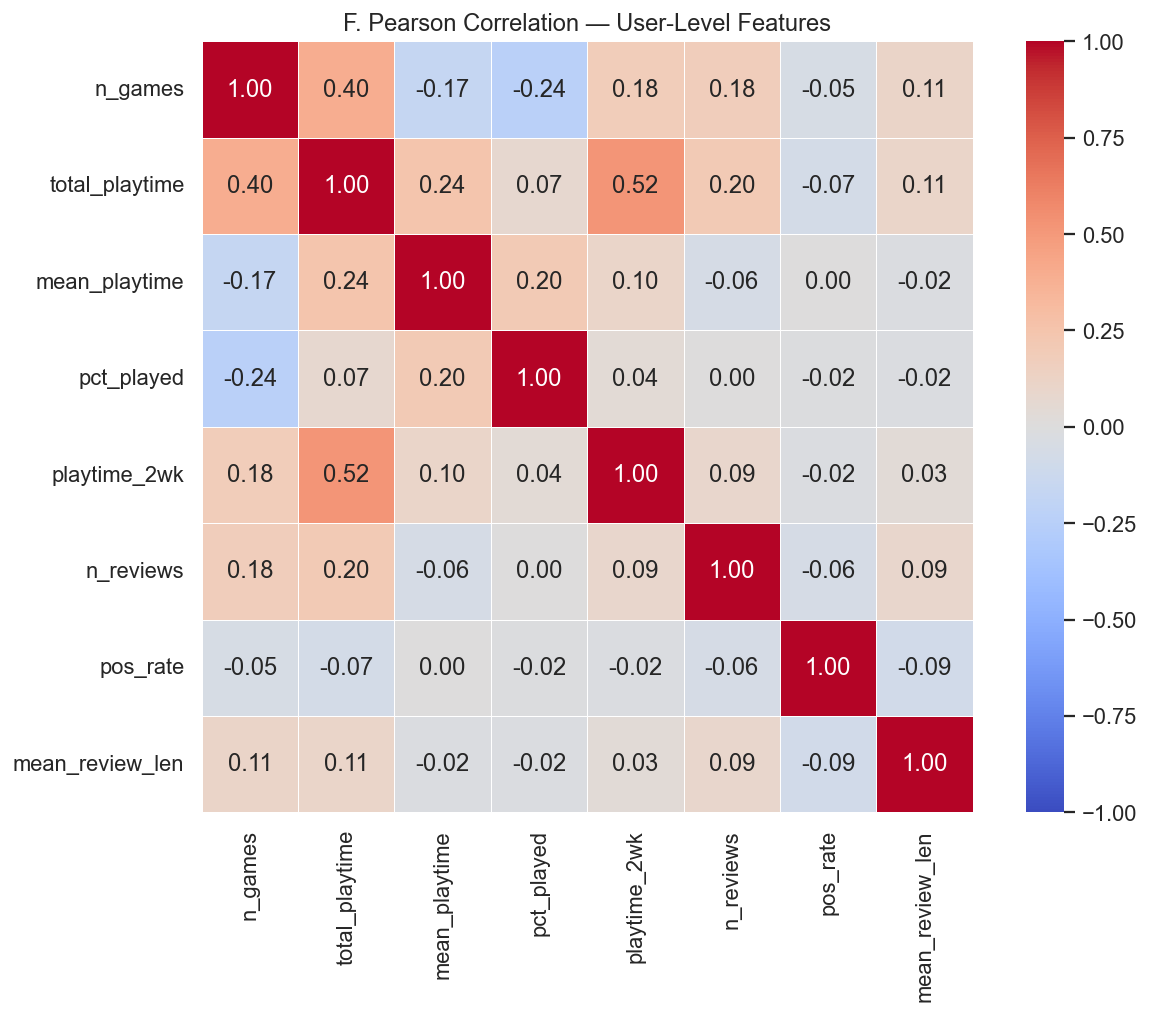

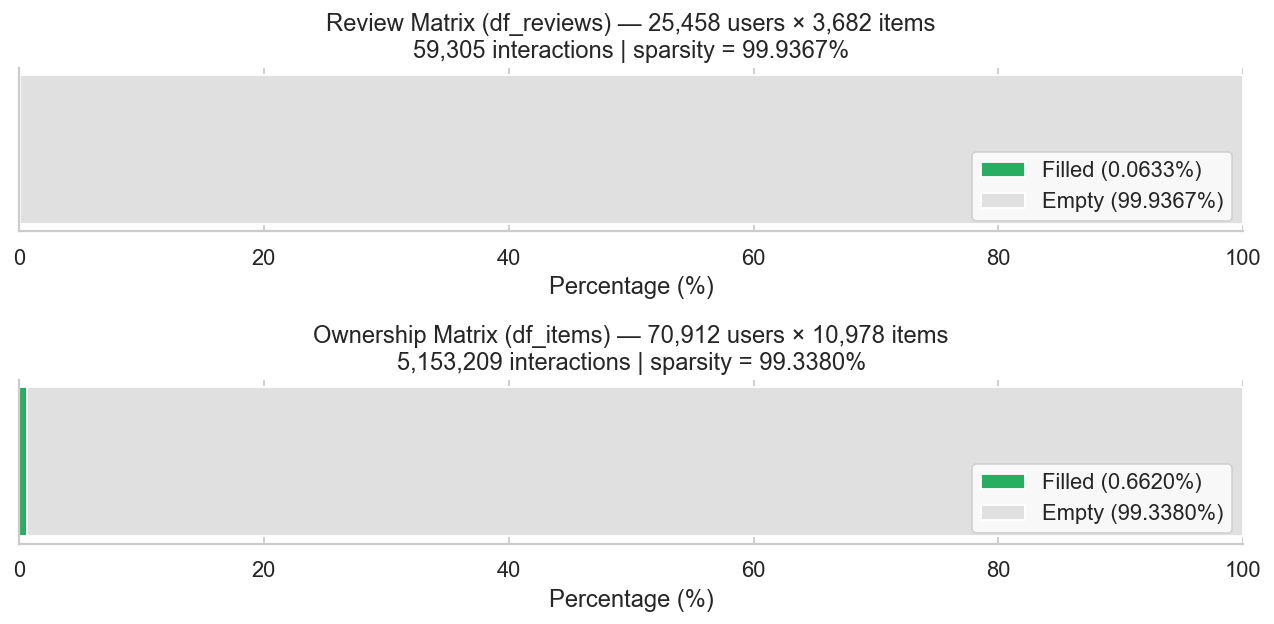

In [10]:
# ── F. Multivariate Analysis ───────────────────────────────────────────────────

# Build user-level feature matrix
user_stats = df_itm.groupby("user_id").agg(
    n_games=("item_id", "nunique"),
    total_playtime=("playtime_forever", "sum"),
    mean_playtime=("playtime_forever", "mean"),
    pct_played=("playtime_forever", lambda x: (x > 0).mean()),
    playtime_2wk=("playtime_2weeks", "sum"),
).reset_index()

user_rev_stats = df_rev.groupby("user_id").agg(
    n_reviews=("item_id", "count"),
    pos_rate=("recommend", "mean"),
    mean_review_len=("review_len", "mean"),
).reset_index()

user_combined = user_stats.merge(user_rev_stats, on="user_id", how="inner")
num_feats = ["n_games", "total_playtime", "mean_playtime", "pct_played",
             "playtime_2wk", "n_reviews", "pos_rate", "mean_review_len"]

corr = user_combined[num_feats].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title("F. Pearson Correlation — User-Level Features")
plt.tight_layout()
plt.show()

# Sparsity
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
plot_sparsity(df_rev["user_id"].nunique(), df_rev["item_id"].nunique(),
              len(df_rev), "Review Matrix (df_reviews)", ax=axes[0])
plot_sparsity(df_itm["user_id"].nunique(), df_itm["item_id"].nunique(),
              len(df_itm), "Ownership Matrix (df_items)", ax=axes[1])
plt.tight_layout()
plt.show()

### G. Outlier & Anomaly Analysis

,column,Q1,Q3,IQR,lower_fence,upper_fence,n_low,n_high,pct_outliers
0,df_items.playtime_forever (played>0),44.0,808.0,764.0,-1102.0,1954.0,0,436754,13.29
1,df_items.playtime_2weeks (>0),17.0,300.0,283.0,-407.5,724.5,0,17553,12.67
2,df_reviews.review_len (>0),30.0,207.0,177.0,-235.5,472.5,0,6484,10.94


=== Top 10 Users by Total Playtime ===


,user_id,playtime_forever,total_hours
0,REBAS_AS_F-T,4660393,77673
1,shinomegami,3303502,55058
2,Sp3ctre,2822860,47048
3,DownSyndromeKid,2790419,46507
4,Terminally-Chill,1734007,28900
5,stopgovtcorruption,1717609,28627
6,Steamified,1693063,28218
7,Cow666,1674805,27913
8,PiozZ,1570365,26173
9,76561198022404680,1378726,22979


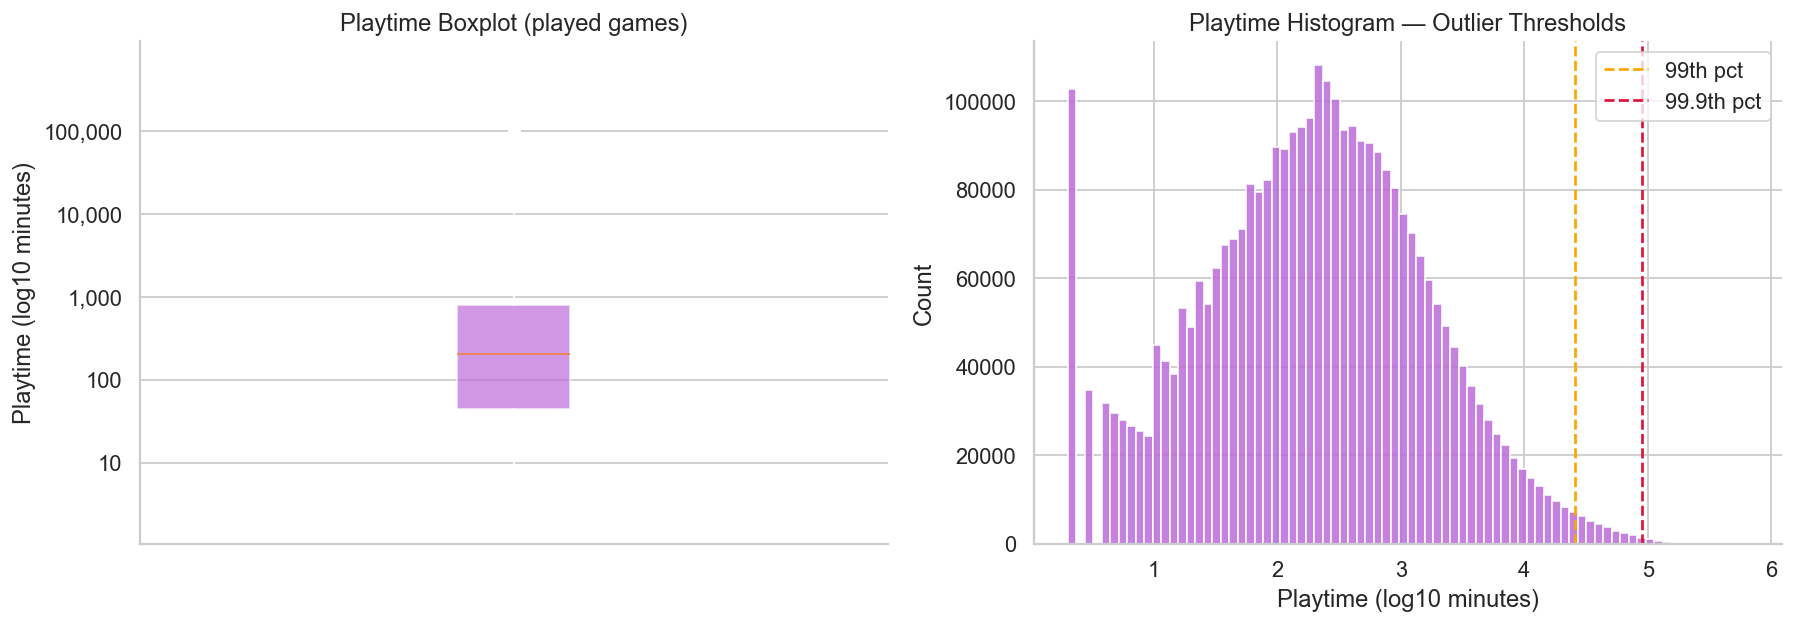


Outlier interpretation:
  playtime_forever : heavy right tail — users with 10,000-50,000+ min are power users
    -> valid extreme behaviour; cap for linear/distance models, keep for tree-based
  review_len       : very long reviews (>10,000 chars) exist — valid; clip for NLP features


In [11]:
# ── G. Outlier & Anomaly Analysis ─────────────────────────────────────────────

def iqr_outliers(series, name):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_lo = (series < lo).sum()
    n_hi = (series > hi).sum()
    return {"column": name,
            "Q1": round(q1, 1), "Q3": round(q3, 1), "IQR": round(iqr, 1),
            "lower_fence": round(lo, 1), "upper_fence": round(hi, 1),
            "n_low": int(n_lo), "n_high": int(n_hi),
            "pct_outliers": round((n_lo + n_hi) / len(series) * 100, 2)}

rows = [
    iqr_outliers(df_itm.loc[df_itm["playtime_forever"] > 0, "playtime_forever"],
                 "df_items.playtime_forever (played>0)"),
    iqr_outliers(df_itm.loc[df_itm["playtime_2weeks"] > 0, "playtime_2weeks"],
                 "df_items.playtime_2weeks (>0)"),
    iqr_outliers(df_rev.loc[df_rev["review_len"] > 0, "review_len"],
                 "df_reviews.review_len (>0)"),
]
display(pd.DataFrame(rows))

# Top extreme users by playtime
print("=== Top 10 Users by Total Playtime ===")
top_u = df_itm.groupby("user_id")["playtime_forever"].sum().nlargest(10).reset_index()
top_u["total_hours"] = (top_u["playtime_forever"] / 60).round(0).astype(int)
display(top_u)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
played = df_itm[df_itm["playtime_forever"] > 0]["playtime_forever"]

axes[0].boxplot(np.log10(played + 1), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#BB6BD9", alpha=0.7))
yticks = [1, 2, 3, 4, 5]
axes[0].set_yticks(yticks)
axes[0].set_yticklabels([f"{10**t:,.0f}" for t in yticks])
axes[0].set_ylabel("Playtime (log10 minutes)")
axes[0].set_title("Playtime Boxplot (played games)")
axes[0].set_xticks([])

axes[1].hist(np.log10(played + 1), bins=80, color="#BB6BD9", edgecolor="white", alpha=0.85)
axes[1].axvline(np.log10(played.quantile(0.99)  + 1), color="orange",  linestyle="--", label="99th pct")
axes[1].axvline(np.log10(played.quantile(0.999) + 1), color="crimson", linestyle="--", label="99.9th pct")
axes[1].set_xlabel("Playtime (log10 minutes)")
axes[1].set_ylabel("Count")
axes[1].set_title("Playtime Histogram — Outlier Thresholds")
axes[1].legend()
plt.tight_layout()
plt.show()

print("""
Outlier interpretation:
  playtime_forever : heavy right tail — users with 10,000-50,000+ min are power users
    -> valid extreme behaviour; cap for linear/distance models, keep for tree-based
  review_len       : very long reviews (>10,000 chars) exist — valid; clip for NLP features""")

### H. Target Analysis

Positive (recommend=True):    52,473  (88.48%)
Negative (recommend=False):    6,832  (11.52%)
Imbalance ratio (pos/neg):  7.68


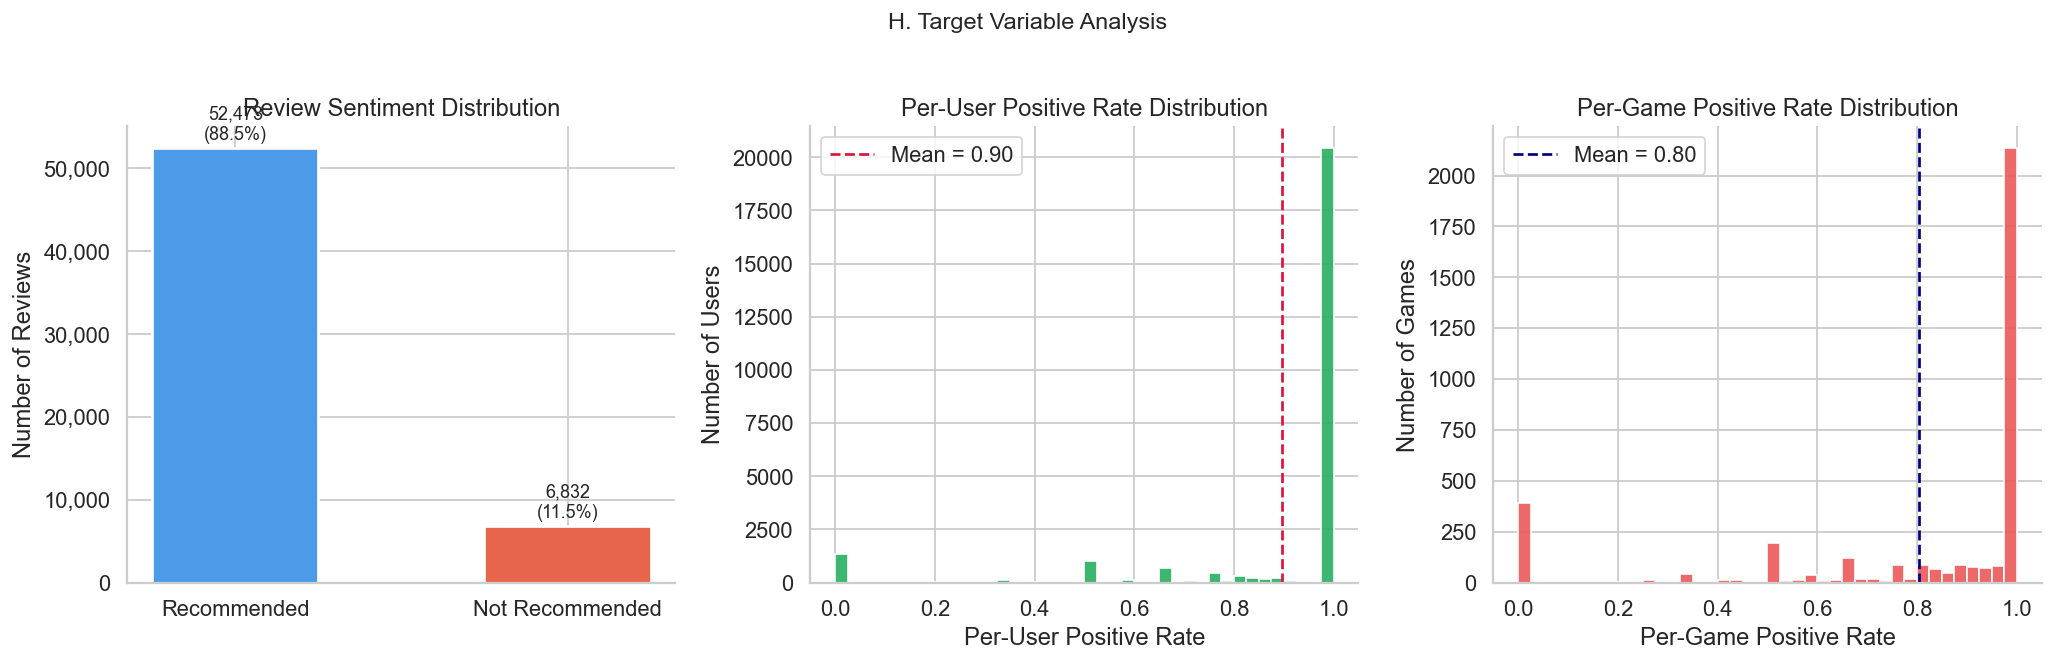


Users who always recommend:  20,440  (80.3%)
Users who never recommend:   1,334  (5.2%)
→ These users carry no within-user signal; consider filtering for pairwise learning-to-rank.

Cold-start items (≤5 reviews): 2,652  (72.0%)


In [12]:
# ── H. Target Analysis (Recommendation Signal) ────────────────────────────────

pos   = df_rev["recommend"].sum()
neg   = (~df_rev["recommend"]).sum()
total = len(df_rev)
print(f"Positive (recommend=True):  {pos:>8,}  ({pos/total*100:.2f}%)")
print(f"Negative (recommend=False): {neg:>8,}  ({neg/total*100:.2f}%)")
print(f"Imbalance ratio (pos/neg):  {pos/neg:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_recommend_distribution(df_rev, ax=axes[0])

user_pos = df_rev.groupby("user_id")["recommend"].mean()
axes[1].hist(user_pos, bins=40, color="#27AE60", edgecolor="white", alpha=0.9)
axes[1].axvline(user_pos.mean(), color="crimson", linestyle="--",
                label=f"Mean = {user_pos.mean():.2f}")
axes[1].set_xlabel("Per-User Positive Rate")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Per-User Positive Rate Distribution")
axes[1].legend()

item_pos = df_rev.groupby("item_id")["recommend"].mean()
axes[2].hist(item_pos, bins=40, color="#EB5757", edgecolor="white", alpha=0.9)
axes[2].axvline(item_pos.mean(), color="navy", linestyle="--",
                label=f"Mean = {item_pos.mean():.2f}")
axes[2].set_xlabel("Per-Game Positive Rate")
axes[2].set_ylabel("Number of Games")
axes[2].set_title("Per-Game Positive Rate Distribution")
axes[2].legend()
plt.suptitle("H. Target Variable Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pure_pos = (user_pos == 1.0).sum()
pure_neg = (user_pos == 0.0).sum()
print(f"\nUsers who always recommend:  {pure_pos:,}  ({pure_pos/len(user_pos)*100:.1f}%)")
print(f"Users who never recommend:   {pure_neg:,}  ({pure_neg/len(user_pos)*100:.1f}%)")
print("→ These users carry no within-user signal; consider filtering for pairwise learning-to-rank.")

item_counts = df_rev.groupby("item_id").size()
print(f"\nCold-start items (≤5 reviews): {(item_counts <= 5).sum():,}  ({(item_counts <= 5).mean()*100:.1f}%)")